# CSI-Based People Counting: Classical ML Pipeline

Notebook ini membangun pipeline machine learning klasik (tanpa deep learning) untuk klasifikasi jumlah orang dalam ruangan berdasarkan Channel State Information (CSI).

Langkah utama:
- Load file `.mat` dari folder dataset
- Preprocessing: imputasi missing value, filtering Savitzky-Golay pada komponen real & imajiner
- Transformasi ke magnitude dan phase
- Windowing di domain waktu untuk menghasilkan banyak sampel
- Ekstraksi fitur statistik per window
- Training model Random Forest dan Gradient Boosting
- Evaluasi akurasi keseluruhan dan per kelas (confusion matrix)

# Import and Config

In [1]:
# Section 1: Set Up Environment and Imports


import os
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


import matplotlib.pyplot as plt
import seaborn as sns


# Import dari utils package
from utils import config
from utils import (
    extract_label_from_filename,
    load_csi_matrix,
    collect_all_mat_files,
    impute_missing_per_subcarrier,
    apply_savgol_per_subcarrier,
    csi_to_mag_phase,
    window_indices,
    extract_features_from_window,
    make_knn_pipeline
)


# Akses konstanta dari config
DATASET_ROOT = config.DATASET_ROOT
PC_FOLDERS = config.PC_FOLDERS
WINDOW_SIZE = config.WINDOW_SIZE
WINDOW_STRIDE = config.WINDOW_STRIDE
RANDOM_STATE = config.RANDOM_STATE
TEST_SIZE = config.TEST_SIZE
VAL_SIZE = config.VAL_SIZE


print("Dataset root:", DATASET_ROOT)
print("PC folders:", PC_FOLDERS)
print("Window size:", WINDOW_SIZE)
print("Window stride:", WINDOW_STRIDE)



Dataset root: dataset
PC folders: ['PC-1a', 'PC-2a', 'PC-3a', 'PC-4a']
Window size: 200
Window stride: 100


In [2]:
# Contoh eksekusi: preprocessing & windowing satu file

example_file = os.path.join(DATASET_ROOT, "PC-3a", "PC3a_n04.mat")
if not os.path.exists(example_file):
    # Fallback: ambil file .mat pertama yang ada
    all_mats = collect_all_mat_files()
    if len(all_mats) == 0:
        raise FileNotFoundError("Tidak ada file .mat ditemukan untuk contoh.")
    example_file = all_mats[0]

print("Contoh file:", example_file)

# Tahap: load -> imputasi -> filter -> mag
csi_example = load_csi_matrix(example_file)
print("CSI shape (raw):", csi_example.shape)

csi_example = impute_missing_per_subcarrier(csi_example)
csi_example = apply_savgol_per_subcarrier(csi_example)
mag_example, _ = csi_to_mag_phase(csi_example)
print("Magnitude shape:", mag_example.shape)

# Windowing sederhana
n_time_ex = mag_example.shape[1]
example_windows = window_indices(n_time_ex, WINDOW_SIZE, WINDOW_STRIDE)
print("Jumlah window contoh:", len(example_windows))

if example_windows:
    start, end = example_windows[0]
    mag_win = mag_example[:, start:end]
    feats_example = extract_features_from_window(mag_win)
    print("Dimensi fitur 1 window:", feats_example.shape)


Contoh file: dataset\PC-3a\PC3a_n04.mat
CSI shape (raw): (242, 202268)
Magnitude shape: (242, 202268)
Jumlah window contoh: 2021
Dimensi fitur 1 window: (1210,)


In [3]:
# Section 3: Bangun full dataset dari semua file

all_files = collect_all_mat_files()
print(f"Ditemukan {len(all_files)} file .mat")


Ditemukan 39 file .mat


In [ ]:
# Ekstraksi fitur dari semua file

X_list = []
y_list = []

for path in all_files:
    print(f"Memproses {os.path.basename(path)} ...")
    label = extract_label_from_filename(path)
    csi = load_csi_matrix(path)
    csi = impute_missing_per_subcarrier(csi)
    csi = apply_savgol_per_subcarrier(csi)
    mag, _ = csi_to_mag_phase(csi)

    n_time = mag.shape[1]
    idx_list = window_indices(n_time, WINDOW_SIZE, WINDOW_STRIDE)

    if not idx_list:
        print("  (Lewat: tidak ada window valid)")
        continue

    for (start, end) in idx_list:
        mag_win = mag[:, start:end]
        feats = extract_features_from_window(mag_win)
        # Debug: pastikan dimensi fitur konsisten
        if len(feats) != 1210:
            print("Dimensi fitur tak terduga:", len(feats), os.path.basename(path))
        X_list.append(feats)
        y_list.append(label)

if not X_list:
    raise RuntimeError("Tidak ada sampel yang berhasil diekstrak dari file mana pun.")


Memproses PC1a_n00.mat ...
Memproses PC1a_n02.mat ...
Memproses PC1a_n03.mat ...
Memproses PC1a_n04.mat ...
Memproses PC1a_n05.mat ...
Memproses PC1a_n06.mat ...
Memproses PC1a_n07.mat ...
Memproses PC1a_n08.mat ...
Memproses PC1a_n09.mat ...
Memproses PC1a_n10.mat ...
Memproses PC2a_n02.mat ...
Memproses PC2a_n03.mat ...
Memproses PC2a_n04.mat ...
Memproses PC2a_n05.mat ...
Memproses PC2a_n06.mat ...
Memproses PC2a_n07.mat ...
Memproses PC2a_n08.mat ...
Memproses PC2a_n09.mat ...
Memproses PC2a_n10.mat ...
Memproses PC3a_n00.mat ...
Memproses PC3a_n02.mat ...
Memproses PC3a_n03.mat ...
Memproses PC3a_n04.mat ...
Memproses PC3a_n05.mat ...
Memproses PC3a_n06.mat ...
Memproses PC3a_n07.mat ...
Memproses PC3a_n08.mat ...
Memproses PC3a_n09.mat ...
Memproses PC3a_n10.mat ...
Memproses PC4a_n00.mat ...
Memproses PC4a_n02.mat ...
Memproses PC4a_n03.mat ...
Memproses PC4a_n04.mat ...
Memproses PC4a_n05.mat ...
Memproses PC4a_n06.mat ...
Memproses PC4a_n07.mat ...
Memproses PC4a_n08.mat ...
M

In [5]:
X_all = np.vstack(X_list)
y_all = np.array(y_list)  # sekarang berisi label string: 'small', 'medium', 'large'

print("Total sampel:", X_all.shape[0])
print("Dimensi fitur per sampel:", X_all.shape[1])
print("Distribusi label (grouped):")
print(pd.Series(y_all).value_counts().sort_index())

print("\nShape X_all:", X_all.shape)
print("Shape y_all:", y_all.shape)

Total sampel: 72586
Dimensi fitur per sampel: 1210
Distribusi label (grouped):
large     22370
medium    29306
small     20910
Name: count, dtype: int64

Shape X_all: (72586, 1210)
Shape y_all: (72586,)


In [ ]:
# Section 3 (opsional): Simpan fitur terproses ke CSV

X_df = pd.DataFrame(X_all)
y_series = pd.Series(y_all, name="label")
df_out = X_df.copy()
df_out["label"] = y_series

# Tentukan folder dan nama file output
preprocessed_dir = os.path.join(DATASET_ROOT, "processed")
os.makedirs(preprocessed_dir, exist_ok=True)
output_csv_path = os.path.join(preprocessed_dir, "csi_windows_features.csv")

# Simpan ke CSV (tanpa index)
df_out.to_csv(output_csv_path, index=False)

print("Data fitur tersimpan ke:", output_csv_path)
print("Shape DataFrame tersimpan:", df_out.shape)


Data fitur tersimpan ke: dataset\processed\csi_windows_features_grouped.csv
Shape DataFrame tersimpan: (72586, 1211)


In [2]:
# Section 3 (opsional): Load fitur terproses dari CSV

preprocessed_dir = os.path.join(DATASET_ROOT, "processed")
input_csv_path = os.path.join(preprocessed_dir, "csi_windows_features.csv")

if not os.path.exists(input_csv_path):
    raise FileNotFoundError(f"File CSV tidak ditemukan: {input_csv_path}. Jalankan dulu cell ekspor fitur.")

df_loaded = pd.read_csv(input_csv_path)

# Asumsikan kolom terakhir adalah 'label' dan sisanya fitur
if "label" not in df_loaded.columns:
    raise ValueError("Kolom 'label' tidak ditemukan di file CSV.")

X_all = df_loaded.drop(columns=["label"]).values
y_all = df_loaded["label"].values  # label string: 'small', 'medium', 'large'

print("Berhasil load fitur dari CSV:")
print("Total sampel:", X_all.shape[0])
print("Dimensi fitur per sampel:", X_all.shape[1])
print("Distribusi label (grouped):")
print(pd.Series(y_all).value_counts().sort_index())

print("\nShape X_all:", X_all.shape)
print("Shape y_all:", y_all.shape)


Berhasil load fitur dari CSV:
Total sampel: 72586
Dimensi fitur per sampel: 1210
Distribusi label (grouped):
0     6116
2     7820
3     6974
4     8041
5     7023
6     6875
7     7367
8     8138
9     6612
10    7620
Name: count, dtype: int64

Shape X_all: (72586, 1210)
Shape y_all: (72586,)


In [3]:
# Section 4: Split Dataset dan Label Encoding

# ================================
# Split train / val / test
# ================================

# Pertama, pisah test set dari total
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

# Dari sisa (X_temp), ambil val_size relatif terhadap total
remaining = 1.0 - TEST_SIZE
val_size_rel_to_temp = VAL_SIZE / remaining

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_size_rel_to_temp,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ================================
# Label Encoding (WAJIB untuk XGBoost)
# ================================

label_encoder = LabelEncoder()

# Fit HANYA di training label (best practice)
y_train = label_encoder.fit_transform(y_train)
y_val   = label_encoder.transform(y_val)
y_test  = label_encoder.transform(y_test)

# Simpan class names asli (untuk report & confusion matrix)
class_names = [str(c) for c in label_encoder.classes_]

print("Kelas asli:", class_names)
print("\nMapping label:")
for i, cls in enumerate(class_names):
    print(f"  {cls} -> {i}")


Train shape: (50810, 1210)
Val shape: (10888, 1210)
Test shape: (10888, 1210)
Kelas asli: ['0', '2', '3', '4', '5', '6', '7', '8', '9', '10']

Mapping label:
  0 -> 0
  2 -> 1
  3 -> 2
  4 -> 3
  5 -> 4
  6 -> 5
  7 -> 6
  8 -> 7
  9 -> 8
  10 -> 9


In [6]:
# Section 5: Training dan Evaluasi kNN
knn_model = make_knn_pipeline()

print("\n====================================")
print("Training kNN Classifier")
print("====================================")

knn_model.fit(X_train, y_train)


Training kNN Classifier


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


Train accuracy: 1.0000
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4281
           2       1.00      1.00      1.00      5474
           3       1.00      1.00      1.00      4882
           4       1.00      1.00      1.00      5629
           5       1.00      1.00      1.00      4916
           6       1.00      1.00      1.00      4813
           7       1.00      1.00      1.00      5157
           8       1.00      1.00      1.00      5696
           9       1.00      1.00      1.00      4628
          10       1.00      1.00      1.00      5334

    accuracy                           1.00     50810
   macro avg       1.00      1.00      1.00     50810
weighted avg       1.00      1.00      1.00     50810



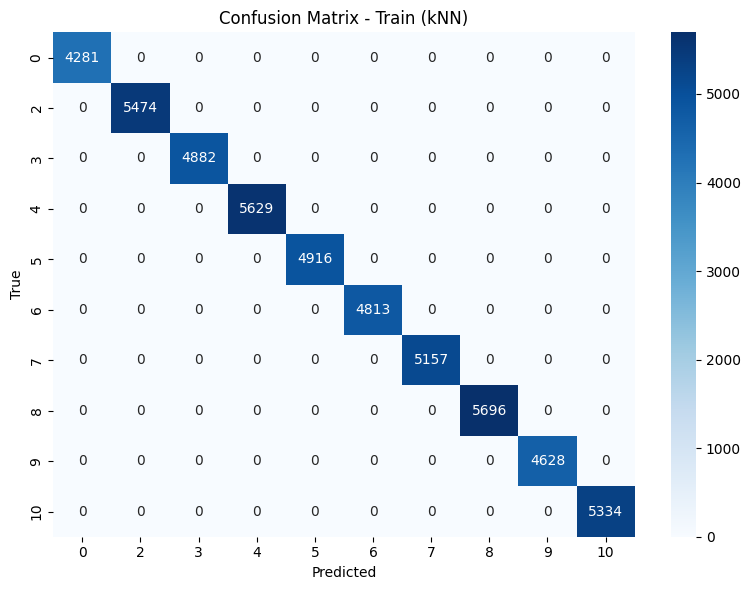


Validation accuracy: 0.8214
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       918
           2       0.89      0.91      0.90      1173
           3       0.76      0.83      0.79      1046
           4       0.81      0.82      0.81      1206
           5       0.79      0.78      0.78      1053
           6       0.74      0.79      0.77      1031
           7       0.81      0.78      0.79      1105
           8       0.82      0.78      0.80      1221
           9       0.80      0.74      0.77       992
          10       0.82      0.80      0.81      1143

    accuracy                           0.82     10888
   macro avg       0.82      0.82      0.82     10888
weighted avg       0.82      0.82      0.82     10888



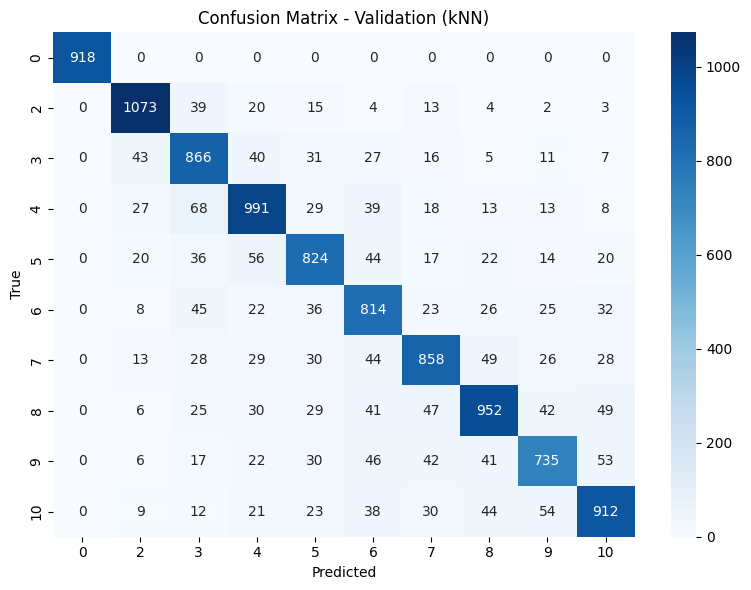


Test accuracy: 0.8207
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       917
           2       0.88      0.92      0.90      1173
           3       0.76      0.85      0.80      1046
           4       0.81      0.80      0.81      1206
           5       0.80      0.77      0.78      1054
           6       0.73      0.77      0.75      1031
           7       0.78      0.80      0.79      1105
           8       0.82      0.78      0.80      1221
           9       0.80      0.74      0.77       992
          10       0.84      0.79      0.82      1143

    accuracy                           0.82     10888
   macro avg       0.82      0.82      0.82     10888
weighted avg       0.82      0.82      0.82     10888



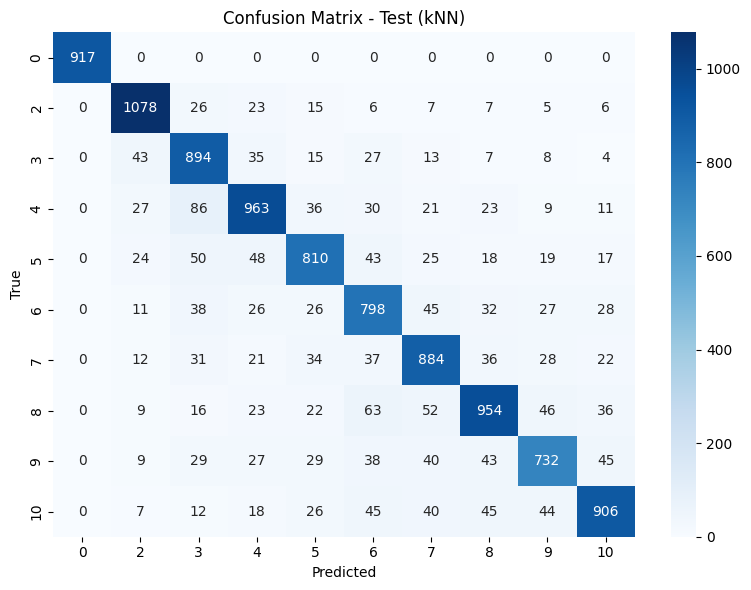

In [5]:
def knn_report_split(name: str, X: np.ndarray, y_true: np.ndarray):
    y_pred = knn_model.predict(X)
    acc = accuracy_score(y_true, y_pred)


    print(f"\n{name} accuracy: {acc:.4f}")
    print("Classification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,   # nama kelas untuk report
        zero_division=0
    ))


    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
)
    plt.title(f"Confusion Matrix - {name} (kNN)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()




# Laporan di train, validation, dan test
knn_report_split("Train", X_train, y_train)
knn_report_split("Validation", X_val, y_val)
knn_report_split("Test", X_test, y_test)

In [4]:
# Section 6: Hyperparameter Tuning untuk kNN dengan GridSearchCV


from sklearn.model_selection import GridSearchCV


# Definisikan search space untuk hyperparameter kNN (step 'clf' di pipeline)
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9, 11],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan", "minkowski"],
}


knn_base = make_knn_pipeline()


grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=2,
)


print("\n====================================")
print("Hyperparameter Tuning kNN (GridSearchCV)")
print("====================================")


grid_search.fit(X_train, y_train)


print("\nBest params:", grid_search.best_params_)
print("Best CV accuracy:", f"{grid_search.best_score_:.4f}")


# Ambil model terbaik dari hasil GridSearch
best_knn = grid_search.best_estimator_


# Evaluasi akurasi di validation dan test set
val_acc = accuracy_score(y_val, best_knn.predict(X_val))
test_acc = accuracy_score(y_test, best_knn.predict(X_test))


print("\nValidation accuracy (best kNN):", f"{val_acc:.4f}")
print("Test accuracy (best kNN):", f"{test_acc:.4f}")


# (Opsional) gunakan kembali fungsi knn_report_split dengan model terbaik


knn_model = best_knn
knn_report_split("Train (tuned)", X_train, y_train)
knn_report_split("Validation (tuned)", X_val, y_val)
knn_report_split("Test (tuned)", X_test, y_test)


Hyperparameter Tuning kNN (GridSearchCV)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Best CV accuracy: 0.6956

Validation accuracy (best kNN): 0.8214
Test accuracy (best kNN): 0.8207


NameError: name 'knn_report_split' is not defined